In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [8]:

# 2. Carregamento e fusão de dados

# 2.1. Carregar dataframe de preditores ERA5/ERA5-Land (supondo CSV ou DataFrame existente)
# ajuste o caminho conforme seu ambiente
era5_df = pd.read_csv("/home/lacrio2/Documentos/LACRIO/PROJETO/LACRIO/Pre-processamento/dados_csv/dados_era5_era5land.csv", parse_dates=["date"])  # contém colunas ['date', 'z_300', ..., 'sf']

# 2.2. Carregar dados da estação local (CSV)
station_df = pd.read_csv("/home/lacrio2/Documentos/LACRIO/PROJETO/LACRIO/Pre-processamento/dados_csv/dados_estacao_cuchillacocha.csv", parse_dates=["data"] )  # colunas ['date', 'temp_obs', 'prec_obs']

station_df = station_df.drop(columns=["Precipitação"])  # Remover coluna indesejada, se necessário
station_df = station_df.rename(
    columns={
        "data": "date",  # Renomear a coluna de data para 'date' para compatibilidade
        "Temperatura": "temp_obs"  # Substitua pelo nome real da coluna de temperatura
    })

# 2.3. Mesclar dados pelo índice temporal
data  = pd.merge(era5_df, station_df, on="date", how="inner")


In [9]:
data = data.dropna()  # Remove colunas com todos os valores NaN

In [11]:

# 3. Incorporação do DEM e cálculo de alt_diff
# Carregar DEM NetCDF (contém variável 'elevation')
dem = xr.open_dataset("/home/lacrio2/Documentos/LACRIO/PROJETO/LACRIO/Dados_DEM/Quilcayhuanca_static.nc")
# Supondo que você conheça as coordenadas da estação
lat_sta, lon_sta = -9.41, -77.35
# Extrair altitude do ponto da estação
elev_local = float(dem['HGT'].sel(lat=lat_sta, lon=lon_sta, method='nearest'))
# Extrair altitude do grid ERA5 (coluna z já está em geopotencial em Pa * m? ou converta)
# Supondo que 'z' seja geopotencial (m2/s2), converter para metros: z_m = z / 9.80665
data['alt_ERA5'] = data['z'] / 9.80665
# Calcular diferença de altitude
data['alt_diff'] = elev_local - data['alt_ERA5']


In [12]:

# 5. Definição de features (X) e alvos (y)
features = [c for c in data.columns if c not in ['date', 'temp_obs']]
X = data[features].copy()
y_temp = data['temp_obs'].copy()

In [13]:

# 6. Divisão treino/teste considerando série temporal
# Reservar os últimos 2 anos para teste (ajuste as datas conforme seus dados)
split_date = '2018-01-01'
train_mask = data['date'] < split_date
X_train, X_test = X[train_mask], X[~train_mask]
y_temp_train, y_temp_test = y_temp[train_mask], y_temp[~train_mask]


In [14]:

# 7. Construção de pipelines e dicionário de modelos para teste
models = {
    'LinearRegression': Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    'RandomForest': Pipeline([('rf', RandomForestRegressor(n_jobs=-1, random_state=42))]),
    'SVR': Pipeline([('scaler', StandardScaler()), ('svr', SVR())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor(max_iter=500, random_state=42))]),
    'XGBoost': Pipeline([('scaler', StandardScaler()), ('xgb', xgb.XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42))]),
}

In [15]:
# 8. Validação inicial com TimeSeriesSplit
# Converter para arrays NumPy para slicing
X_train_arr = X_train.values
y_temp_arr = y_temp_train.values

# Definir divisão temporal com 5 folds
ts = TimeSeriesSplit(n_splits=5)
results_temp = {}
for name, pipeline in models.items():
    rmses = []
    for train_idx, val_idx in ts.split(X_train_arr):
        X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
        y_tr, y_val = y_temp_arr[train_idx], y_temp_arr[val_idx]
        # Garante não haver NaNs no subset de treino
        mask_notnan = ~np.isnan(y_tr)
        X_tr_f, y_tr_f = X_tr[mask_notnan], y_tr[mask_notnan]
        pipeline.fit(X_tr_f, y_tr_f)
        y_pred = pipeline.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, y_pred)))
    results_temp[name] = np.mean(rmses)
print("RMSE médio (validação) - Temperatura:", results_temp)

/home/lacrio2/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/lacrio2/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/lacrio2/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/lacrio2/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/lacrio2/miniconda3/lib

RMSE médio (validação) - Temperatura: {'LinearRegression': np.float64(0.8394493963028404), 'RandomForest': np.float64(0.8755665601390069), 'SVR': np.float64(0.9194606930922372), 'MLP': np.float64(3.6406428592284548), 'XGBoost': np.float64(0.9528130859015519)}


In [16]:
# 9. GridSearchCV para RandomForest (Temperatura)
grid_rf = GridSearchCV(
    models['RandomForest'],
    param_grid={
        'rf__n_estimators': [100, 200],
        'rf__max_depth': [None, 10, 20],
        'rf__min_samples_leaf': [1, 5]
    },
    cv=ts,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_rf.fit(X_train, y_temp_train)
print("Melhores parâmetros RF:", grid_rf.best_params_)
print("Melhor RMSE (CV):", np.sqrt(-grid_rf.best_score_))


Melhores parâmetros RF: {'rf__max_depth': None, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 100}
Melhor RMSE (CV): 0.8947273878496315


In [17]:


# 10. Avaliação no conjunto de teste (Temperatura)
best_rf = grid_rf.best_estimator_
best_rf.fit(X_train, y_temp_train)
y_temp_pred = best_rf.predict(X_test)
print(
    "Teste Temperatura ->",
    "RMSE=", np.sqrt(mean_squared_error(y_temp_test, y_temp_pred)),
    "MAE=", mean_absolute_error(y_temp_test, y_temp_pred),
    "R2=", r2_score(y_temp_test, y_temp_pred)
)

Teste Temperatura -> RMSE= 0.732944542605365 MAE= 0.5819525358124539 R2= 0.5416175792555179


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# === 1) Define pipelines com os parâmetros finais ===
pipelines = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr',      LinearRegression())
    ]),
    'DecisionTree': Pipeline([
        ('scaler', StandardScaler()),
        ('dt', DecisionTreeRegressor(
            max_depth=None,
            min_samples_leaf=1,
            random_state=42
        ))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestRegressor(
            n_estimators=100,
            min_samples_leaf=5,
            max_depth=None,
            random_state=42
        ))
    ]),
    'ExtraTrees': Pipeline([
        ('scaler', StandardScaler()),
        ('et', ExtraTreesRegressor(
            n_estimators=100,
            min_samples_leaf=5,
            max_depth=None,
            random_state=42
        ))
    ]),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(
            use_label_encoder=False,
            eval_metric='rmse',
            random_state=42
        ))
    ]),
}


In [21]:

# === 2) Treino final em todo o conjunto de treino ===
# Certifique-se que X_temp_train e y_temp_train existem no escopo
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_temp_train)


/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [12:52:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/home/lacrio2/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


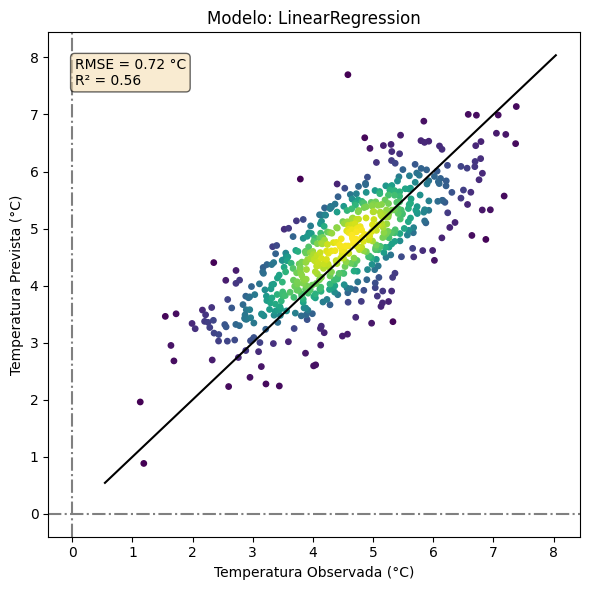

/home/lacrio2/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


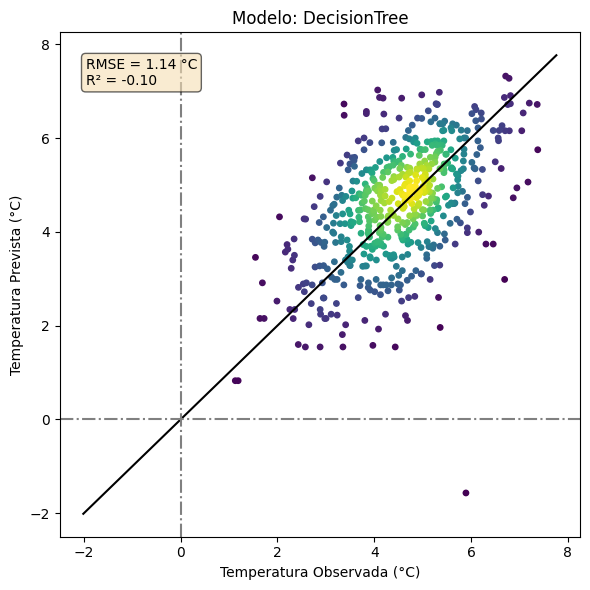

/home/lacrio2/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


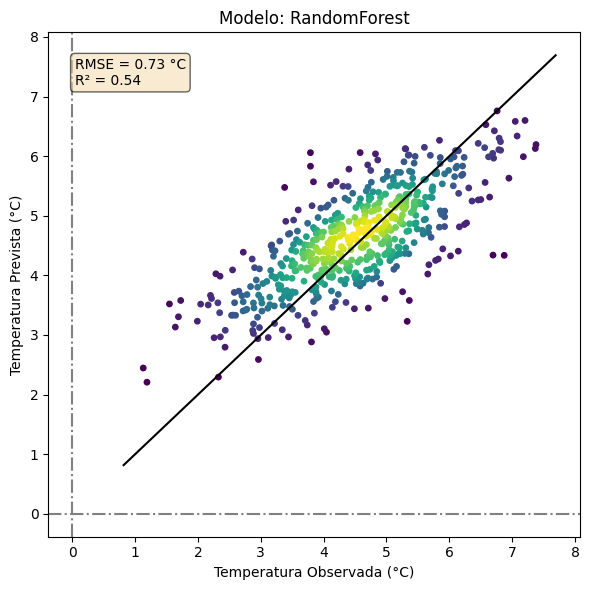

/home/lacrio2/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


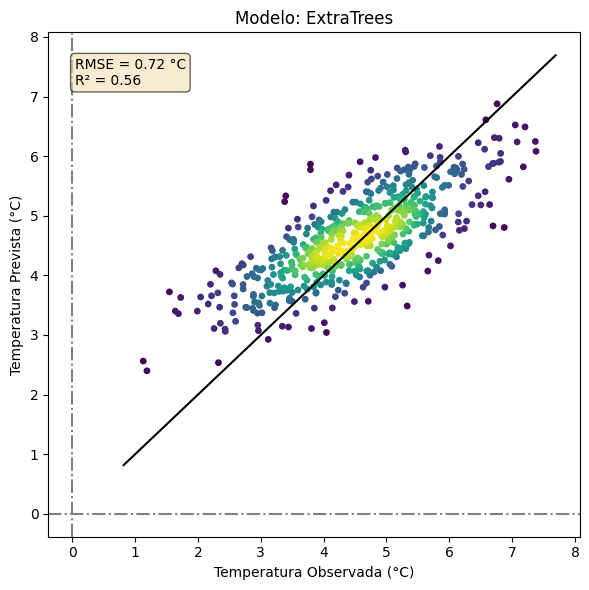

/home/lacrio2/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


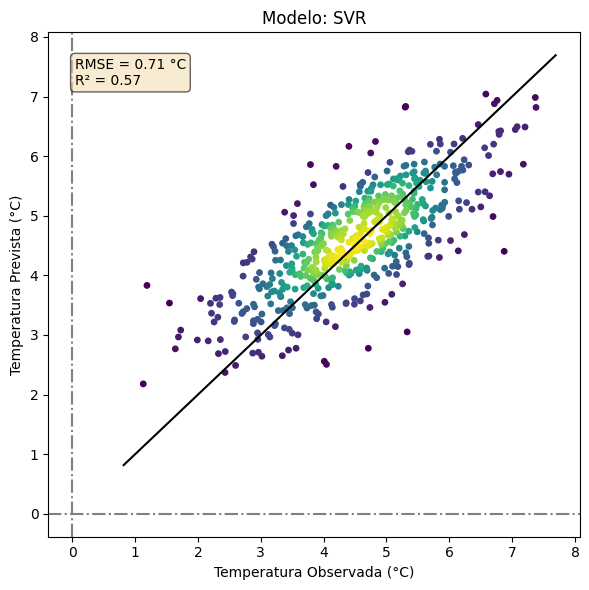

/home/lacrio2/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


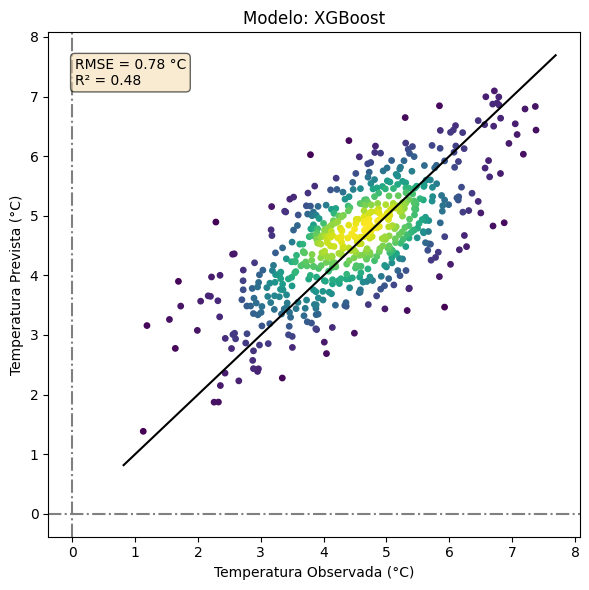

In [22]:

# === 3) Função para plotar scatter colorido por densidade ===
def plot_density_scatter(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    # Calcula densidade com KDE
    xy = np.vstack([y_true, y_pred])
    z  = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = y_true[idx], y_pred[idx], z[idx]

    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(x, y, c=z, s=15)
    # Linha 1:1
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, '-', color='black')
    # Linhas x=0 e y=0
    ax.axhline(0, linestyle='dashdot', color='gray')
    ax.axvline(0, linestyle='dashdot', color='gray')

    ax.set_title(f"Modelo: {model_name}")
    ax.set_xlabel("Temperatura Observada (°C)")
    ax.set_ylabel("Temperatura Prevista (°C)")

    ax.text(
        0.05, 0.95,
        f"RMSE = {rmse:.2f} °C\nR² = {r2:.2f}",
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='wheat', alpha=0.6)
    )
    plt.tight_layout()
    plt.show()

# === 4) Avaliação gráfica em X_temp_test / y_temp_test ===
# Atenção: deve existir em memória X_temp_test e y_temp_test
X_test_arr   = X_test.to_numpy()
y_test_arr   = y_temp_test.to_numpy()

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test_arr)
    plot_density_scatter(y_test_arr, y_pred, name)


In [ ]:


# 11. GridSearchCV para XGBoost (Precipitação)
grid_prec = GridSearchCV(
    models['XGBoost'],
    param_grid={
        'xgb__n_estimators': [100, 200],
        'xgb__max_depth': [3, 6]
    },
    cv=ts,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_prec.fit(X_train, y_prec_train)
print("Melhores parâmetros XGBoost:", grid_prec.best_params_)
print("Melhor RMSE (CV):", np.sqrt(-grid_prec.best_score_))

# 12. Avaliação no conjunto de teste (Precipitação)
best_xgb = grid_prec.best_estimator_
y_prec_pred = best_xgb.predict(X_test)
print(
    "Teste Precipitação ->",
    "RMSE=", np.sqrt(mean_squared_error(y_prec_test, y_prec_pred)),
    "MAE=", mean_absolute_error(y_prec_test, y_prec_pred),
    "R2=", r2_score(y_prec_test, y_prec_pred)
)

# 13. Geração de série histórica downscaled
era_all = pd.read_csv(
    "/caminho/para/era5_features_completo.csv",
    parse_dates=['date']
)
era_all['alt_ERA5'] = era_all['z'] / 9.80665
era_all['alt_diff'] = elev_local - era_all['alt_ERA5']

# Remover NaNs antes de aplicar modelos
era_all = era_all.dropna().reset_index(drop=True)
X_all = era_all[features].values
era_all['temp_downscaled'] = best_rf.predict(X_all)
era_all['prec_downscaled'] = best_xgb.predict(X_all)
era_all[['date', 'temp_downscaled', 'prec_downscaled']].to_csv(
    "downscaled_series.csv", index=False
)

# 14. Placeholder para mapas espaciais
dem_full = xr.open_dataset("/caminho/para/dem.nc")
# Para cada célula: extrair variáveis ERA5 e aplicar modelo downscaled

# Fim do notebook


In [ ]:

# 9. Ajuste de hiperparâmetros via GridSearchCV (exemplo para RandomForest)
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_leaf': [1, 5]
}
grid_rf = GridSearchCV(models['RandomForest'], param_grid, cv=ts, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_temp_train)
print("Melhores parâmetros RF:", grid_rf.best_params_)
print("Melhor RMSE RF:", -grid_rf.best_score_)

# 10. Treinar modelo final com melhores parâmetros e avaliar no teste
best_rf = grid_rf.best_estimator_
best_rf.fit(X_train, y_temp_train)
y_temp_pred = best_rf.predict(X_test)
print("Temperatura Teste: RMSE=", mean_squared_error(y_temp_test, y_temp_pred, squared=False),
      "MAE=", mean_absolute_error(y_temp_test, y_temp_pred),
      "R2=", r2_score(y_temp_test, y_temp_pred))

# 11. Repetir para precipitação (defina seu próprio param_grid se desejar)
grid_prec = GridSearchCV(models['XGBoost'], {'xgb__n_estimators':[100,200], 'xgb__max_depth':[3,6]}, cv=ts, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_prec.fit(X_train, y_prec_train)
best_xgb_prec = grid_prec.best_estimator_
y_prec_pred = best_xgb_prec.predict(X_test)
print("Precipitação Teste: RMSE=", mean_squared_error(y_prec_test, y_prec_pred, squared=False),
      "MAE=", mean_absolute_error(y_prec_test, y_prec_pred),
      "R2=", r2_score(y_prec_test, y_prec_pred))

# 12. Aplicação do modelo para gerar série histórica downscaled
# Use era5_df completo (até 1940) para gerar previsões
era_all = pd.read_csv("/caminho/para/era5_features_completo.csv", parse_dates=['date'])
# Repetir cálculo de alt_diff para era_all conforme acima
era_all['alt_ERA5'] = era_all['z'] / 9.80665
era_all['alt_diff'] = elev_local - era_all['alt_ERA5']
X_all = era_all[features]
# Previsões:
era_all['temp_downscaled'] = best_rf.predict(X_all)
era_all['prec_downscaled'] = best_xgb_prec.predict(X_all)

# 13. Exportar resultados
era_all[['date', 'temp_downscaled', 'prec_downscaled']].to_csv("downscaled_series.csv", index=False)

# 14. (Opcional) Geração de mapas espaciais: placeholder para interpolação de ERA5 ao grid do DEM
# -- Carregue grade do DEM para toda área --
dem_full = xr.open_dataset("/caminho/para/dem.nc")
# -- Para cada célula (lat, lon) do DEM, extrair ERA5 interpolado e aplicar modelo --
# << o código específico vai depender do formato de entrada e tamanho de grade >>

# Fim do Notebook
